In [5]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.feature_extraction import FeatureHasher

import warnings
warnings.filterwarnings('ignore')


# Load datasets

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("=" * 60)
print("HOUSE PRICES DATASET LOADED")
print("=" * 60)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nFirst five rows:")
display(train_df.head())

HOUSE PRICES DATASET LOADED
Training dataset shape: (1460, 81)
Testing dataset shape: (1459, 80)

First five rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# House Prices - Feature Engineering

## Topic: Dataset Exploration

**Notes:**  
The House Prices dataset contains information about residential properties and their characteristics. The objective is to predict the final sale price of each house.

In this project, different feature engineering and categorical encoding techniques will be compared to determine how they affect the performance of a machine learning regression model.

The encoding techniques investigated are:

- Label Encoding
- One-Hot Encoding
- Frequency Encoding
- Binary Encoding
- Feature Hashing

Model performance will be evaluated using RMSE and R².

In [8]:
# ============================================================
# TOPIC: DATASET EXPLORATION
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nDataset shape:")
print(train_df.shape)

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nData types:")
display(train_df.dtypes)

print("\nMissing values:")
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

display(missing_values)

print("\nTarget variable statistics:")
display(train_df['SalePrice'].describe())

DATASET INFORMATION

Dataset shape:
(1460, 81)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'En

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


Missing values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Target variable statistics:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Topic: Separate Features and Target

**Notes:**  
`SalePrice` is the target variable because it is the value we want the model to predict.

All remaining columns are potential predictive features.

The target is separated from the input features before preprocessing so that the model does not accidentally use the answer as an input.

In [10]:
# ============================================================
# TOPIC: SEPARATE FEATURES AND TARGET
# ============================================================

X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

print("Number of input features:", X.shape[1])
print("Number of observations:", X.shape[0])

print("\nTarget variable:")
print("SalePrice")

print("\nTarget range:")
print("Minimum:", y.min())
print("Maximum:", y.max())
print("Mean:", round(y.mean(), 2))

Number of input features: 80
Number of observations: 1460

Target variable:
SalePrice

Target range:
Minimum: 34900
Maximum: 755000
Mean: 180921.2


## Topic: Train-Test Split

**Notes:**  
The dataset is divided into training and validation sets.

The training data is used to learn patterns from the houses, while the validation data is kept separate to evaluate how well the model performs on unseen houses.

A fixed random state is used so that the experiment can be reproduced.

In [13]:
# ============================================================
# TOPIC: TRAIN-TEST SPLIT
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_valid.shape[0])

Training samples: 1168
Validation samples: 292


## Topic: Identify Numerical and Categorical Features

**Notes:**  
Numerical features contain quantities such as area, number of rooms, and year.

Categorical features contain descriptive categories such as neighborhood, house style, and building type.

The two groups require different preprocessing techniques.

In [15]:
# ============================================================
# TOPIC: IDENTIFY FEATURE TYPES
# ============================================================

categorical_columns = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Number of numerical features:", len(numerical_columns))
print("Number of categorical features:", len(categorical_columns))

print("\nCategorical features:")
print(categorical_columns)

print("\nNumerical features:")
print(numerical_columns)

Number of numerical features: 37
Number of categorical features: 43

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Numerical features:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'Kitche

## Topic: Handle Missing Values

**Notes:**  
The dataset contains missing values.

For numerical variables, missing values are replaced using the median of the training data.

For categorical variables, missing values are replaced using the most frequent category.

Using information from the training data only helps prevent data leakage.

In [37]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Create copies of the training and validation data
X_train_clean = X_train.copy()
X_valid_clean = X_valid.copy()

# Handle missing values in numerical features
for column in numerical_columns:
    median_value = X_train_clean[column].median()
    
    X_train_clean[column] = X_train_clean[column].fillna(median_value)
    X_valid_clean[column] = X_valid_clean[column].fillna(median_value)

# Handle missing values in categorical features
for column in categorical_columns:
    mode_value = X_train_clean[column].mode()[0]
    
    X_train_clean[column] = X_train_clean[column].fillna(mode_value)
    X_valid_clean[column] = X_valid_clean[column].fillna(mode_value)

# Check whether missing values remain
print("Missing values in training data:", X_train_clean.isnull().sum().sum())
print("Missing values in validation data:", X_valid_clean.isnull().sum().sum())

print("\nTraining data shape:", X_train_clean.shape)
print("Validation data shape:", X_valid_clean.shape)

Missing values in training data: 0
Missing values in validation data: 0

Training data shape: (1168, 80)
Validation data shape: (292, 80)


# Categorical Encoding Experiments

## Topic: Encoding Comparison

**Notes:**  
Machine learning algorithms generally require numerical input.

Categorical variables therefore need to be transformed into numerical representations.

Five encoding techniques will be tested:

1. Label Encoding
2. One-Hot Encoding
3. Frequency Encoding
4. Binary Encoding
5. Feature Hashing

The same regression model will be used for each method so that the encoding techniques can be compared fairly.

In [34]:
# ============================================================
# TOPIC: MODEL EVALUATION FUNCTION
# ============================================================

results = []


def evaluate_regression(
    X_train_encoded,
    X_valid_encoded,
    method_name
):
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0))
    ])
    
    model.fit(
        X_train_encoded,
        np.log1p(y_train)
    )
    
    predictions_log = model.predict(X_valid_encoded)
    
    # Convert predictions back to original SalePrice scale
    predictions = np.expm1(predictions_log)
    
    rmse = np.sqrt(
        mean_squared_error(y_valid, predictions)
    )
    
    r2 = r2_score(
        y_valid,
        predictions
    )
    
    results.append({
        'Encoding Method': method_name,
        'Number of Features': X_train_encoded.shape[1],
        'RMSE': rmse,
        'R2 Score': r2
    })
    
    print("\n" + "=" * 60)
    print(method_name)
    print("=" * 60)
    
    print("Number of features:", X_train_encoded.shape[1])
    print("RMSE:", round(rmse, 2))
    print("R² Score:", round(r2, 4))

## Topic: Label Encoding

**Notes:**  
Label Encoding assigns an integer to each category.

For example:

- `Male` → 0
- `Female` → 1

For House Prices, every categorical column receives numerical category labels.

This method produces a relatively small number of features, but the numerical values may incorrectly suggest an ordering between categories.

In [38]:
# ============================================================
# TOPIC: LABEL ENCODING
# ============================================================

X_train_label = X_train_clean.copy()
X_valid_label = X_valid_clean.copy()

for column in categorical_columns:
    
    categories = X_train_clean[column].astype(str).unique()
    
    mapping = {
        category: index
        for index, category in enumerate(categories)
    }
    
    X_train_label[column] = (
        X_train_clean[column]
        .astype(str)
        .map(mapping)
    )
    
    X_valid_label[column] = (
        X_valid_clean[column]
        .astype(str)
        .map(mapping)
        .fillna(-1)
    )

evaluate_regression(
    X_train_label.values,
    X_valid_label.values,
    'Label Encoding'
)


Label Encoding
Number of features: 80
RMSE: 27656.72
R² Score: 0.9003


## Topic: One-Hot Encoding

**Notes:**  
One-Hot Encoding creates a separate binary feature for each category.

For example, if a feature contains:

- Red
- Blue
- Green

it can become separate columns representing whether each observation belongs to a particular category.

This avoids imposing an artificial numerical ordering, but it can create many additional features when categorical variables contain many unique values.

In [ ]:
# ============================================================
# TOPIC: ONE-HOT ENCODING
# ============================================================

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = ohe.fit_transform(
    X_train_clean[categorical_columns]
)

X_valid_cat = ohe.transform(
    X_valid_clean[categorical_columns]
)

X_train_ohe = np.hstack([
    X_train_clean[numerical_columns].values,
    X_train_cat
])

X_valid_ohe = np.hstack([
    X_valid_clean[numerical_columns].values,
    X_valid_cat
])

evaluate_regression(
    X_train_ohe,
    X_valid_ohe,
    'One-Hot Encoding'
)

## Topic: Frequency Encoding

**Notes:**  
Frequency Encoding replaces each category with the frequency with which that category appears in the training data.

For example, if a neighborhood occurs in 10% of the training records, its encoded value becomes 0.10.

This can represent the popularity or prevalence of categories while using only one numerical feature per categorical column.

In [40]:
# ============================================================
# TOPIC: FREQUENCY ENCODING
# ============================================================

X_train_freq = X_train_clean.copy()
X_valid_freq = X_valid_clean.copy()

for column in categorical_columns:
    
    frequency_mapping = (
        X_train_clean[column]
        .value_counts(normalize=True)
        .to_dict()
    )
    
    X_train_freq[column] = (
        X_train_clean[column]
        .map(frequency_mapping)
        .fillna(0)
    )
    
    X_valid_freq[column] = (
        X_valid_clean[column]
        .map(frequency_mapping)
        .fillna(0)
    )

evaluate_regression(
    X_train_freq.values,
    X_valid_freq.values,
    'Frequency Encoding'
)


Frequency Encoding
Number of features: 80
RMSE: 27510.3
R² Score: 0.9013


In [ ]:
## Topic: Binary Encoding

**Notes:**  
Binary Encoding first assigns each category an integer and then represents that integer using binary digits.

This can use fewer columns than One-Hot Encoding when a categorical feature has many unique categories.

It provides a compact numerical representation of categorical information.

In [41]:
# ============================================================
# TOPIC: BINARY ENCODING
# ============================================================

def binary_encode(
    train_column,
    valid_column,
    column_name
):
    
    categories = train_column.astype(str).unique()
    
    mapping = {
        category: index
        for index, category in enumerate(categories)
    }
    
    train_numbers = (
        train_column
        .astype(str)
        .map(mapping)
        .fillna(0)
        .astype(int)
    )
    
    valid_numbers = (
        valid_column
        .astype(str)
        .map(mapping)
        .fillna(0)
        .astype(int)
    )
    
    number_of_categories = len(categories)
    
    number_of_bits = max(
        1,
        int(np.ceil(
            np.log2(number_of_categories)
        ))
    )
    
    train_binary = pd.DataFrame(
        index=train_column.index
    )
    
    valid_binary = pd.DataFrame(
        index=valid_column.index
    )
    
    for bit in range(number_of_bits):
        
        train_binary[
            f'{column_name}_binary_{bit}'
        ] = (
            train_numbers // (2 ** bit)
        ) % 2
        
        valid_binary[
            f'{column_name}_binary_{bit}'
        ] = (
            valid_numbers // (2 ** bit)
        ) % 2
    
    return train_binary, valid_binary


X_train_binary = X_train_clean[numerical_columns].copy()
X_valid_binary = X_valid_clean[numerical_columns].copy()

for column in categorical_columns:
    
    train_binary, valid_binary = binary_encode(
        X_train_clean[column],
        X_valid_clean[column],
        column
    )
    
    X_train_binary = pd.concat(
        [X_train_binary, train_binary],
        axis=1
    )
    
    X_valid_binary = pd.concat(
        [X_valid_binary, valid_binary],
        axis=1
    )

evaluate_regression(
    X_train_binary.values,
    X_valid_binary.values,
    'Binary Encoding'
)


Binary Encoding
Number of features: 149
RMSE: 28050.21
R² Score: 0.8974


## Topic: Feature Hashing

**Notes:**  
Feature Hashing uses a hashing function to map categorical values into a fixed number of numerical features.

Unlike One-Hot Encoding, the number of output features can be controlled in advance.

This can be useful for datasets containing very high-cardinality categorical variables because it avoids creating a separate column for every category.

In [42]:
# ============================================================
# TOPIC: FEATURE HASHING
# ============================================================

HASH_FEATURES = 32


def create_hash_data(data):
    
    hash_data = []
    
    for _, row in data.iterrows():
        
        record = {}
        
        for column in categorical_columns:
            
            key = f'{column}={str(row[column])}'
            record[key] = 1
        
        hash_data.append(record)
    
    return hash_data


train_hash_data = create_hash_data(
    X_train_clean
)

valid_hash_data = create_hash_data(
    X_valid_clean
)


hasher = FeatureHasher(
    n_features=HASH_FEATURES,
    input_type='dict'
)

X_train_hash_cat = hasher.transform(
    train_hash_data
).toarray()

X_valid_hash_cat = hasher.transform(
    valid_hash_data
).toarray()


X_train_hash = np.hstack([
    X_train_clean[numerical_columns].values,
    X_train_hash_cat
])

X_valid_hash = np.hstack([
    X_valid_clean[numerical_columns].values,
    X_valid_hash_cat
])


evaluate_regression(
    X_train_hash,
    X_valid_hash,
    'Feature Hashing'
)


Feature Hashing
Number of features: 69
RMSE: 28391.8
R² Score: 0.8949


In [ ]:
# Topic: Encoding Performance Comparison

**Notes:**  
The results from all encoding techniques are collected into one table.

RMSE measures the average prediction error in the original house-price scale. Lower RMSE is better.

R² measures how much of the variation in house prices is explained by the model. Higher R² is better.

The encoding methods can therefore be compared using both metrics.

In [43]:
# ============================================================
# TOPIC: FINAL ENCODING COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='RMSE'
).reset_index(drop=True)

results_df['RMSE'] = results_df['RMSE'].round(2)
results_df['R2 Score'] = results_df['R2 Score'].round(4)

print("=" * 70)
print("FINAL ENCODING COMPARISON")
print("=" * 70)

display(results_df)

FINAL ENCODING COMPARISON


,Encoding Method,Number of Features,RMSE,R2 Score
0,Frequency Encoding,80,27510.30,0.9013
1,Label Encoding,80,27656.72,0.9003
2,Binary Encoding,149,28050.21,0.8974
3,Feature Hashing,69,28391.80,0.8949


In [ ]:
## Topic: Identify the Best Encoding Method

**Notes:**  
The best encoding method is selected using RMSE because this metric directly measures prediction error.

The method with the lowest RMSE provides the most accurate predictions for this experiment.

In [44]:
# ============================================================
# TOPIC: BEST ENCODING METHOD
# ============================================================

best_result = results_df.loc[
    results_df['RMSE'].idxmin()
]

print("=" * 60)
print("BEST PERFORMING ENCODING")
print("=" * 60)

print("Method:", best_result['Encoding Method'])
print("RMSE:", best_result['RMSE'])
print("R² Score:", best_result['R2 Score'])
print(
    "Number of features:",
    int(best_result['Number of Features'])
)

BEST PERFORMING ENCODING
Method: Frequency Encoding
RMSE: 27510.3
R² Score: 0.9013
Number of features: 80


In [ ]:
# Topic: Visual Comparison

**Notes:**  
A bar chart is used to visually compare the prediction error produced by each encoding technique.

Because RMSE represents prediction error, a shorter bar represents better performance.

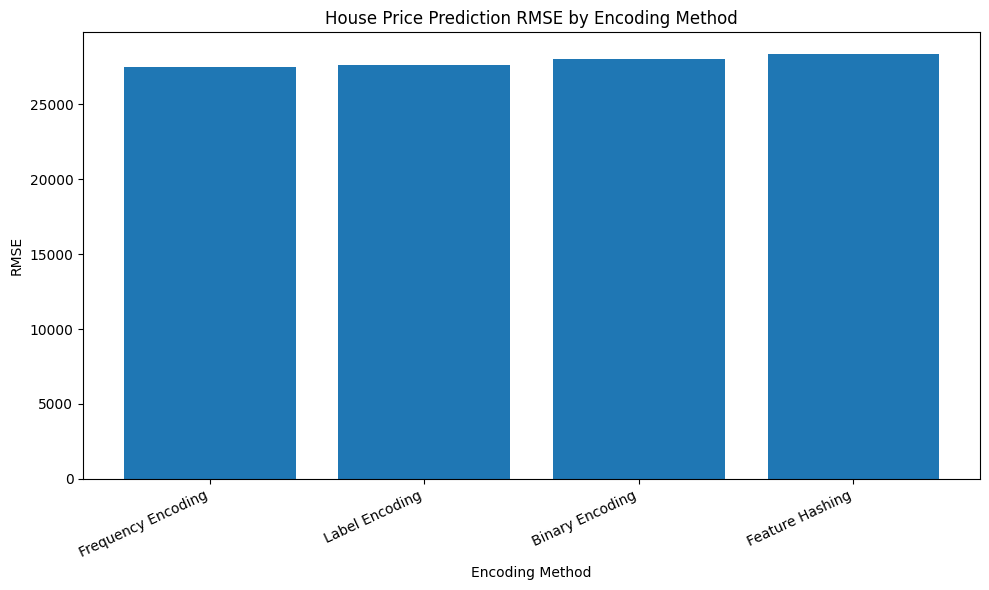

In [45]:
# ============================================================
# TOPIC: VISUAL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Encoding Method'],
    results_df['RMSE']
)

plt.xlabel('Encoding Method')
plt.ylabel('RMSE')
plt.title('House Price Prediction RMSE by Encoding Method')

plt.xticks(
    rotation=25,
    ha='right'
)

plt.tight_layout()
plt.show()